# The normal distribution

## Problem 7-14
On a final examination in mathematics, the mean was $72$ and the standard deviation was $15$. Determine the standard scores (i.e., grades in standard-deviation units) of students receiving the grades (a) 60, (b) 93, and (c) 72.

### Solution

(a)
\begin{align}
z = \frac{X - \bar{X}}{s} = \frac{60 - 72}{15} = -0.8
\end{align}
(b)
\begin{align}
z = \frac{X - \bar{X}}{s} = \frac{93 - 72}{15} = 1.4
\end{align}
(c)
\begin{align}
z = \frac{X - \bar{X}}{s} = \frac{72 - 72}{15} = 0
\end{align}

---

## Problem 7-15
Referring to Problem 7-14, find the grades corresponding to the standard scores (a) -1 and (b) 1.6.

### Solution
(a)
\begin{align}
X = \bar{X} + sz = 72 + (-1)(15) = 57
\end{align}
(b)
\begin{align}
X = \bar{X} + sz = 72 + (1.6)(15) = 96
\end{align}

---

## Problem 7-16
Suppose the number of games in which major league baseball players play during their careers is normally distributed with mean equal to $1500$ games and standard deviation equal to $350$ games. (a) What percentage play in fewer than $750$ games? (b) What percentage play in more than $2000$ games? (c) Find the 90th percentile for the number of games played during a career.

### Solution

In [1]:
cat("(a) percentage play in fewer than 750 games: ", pnorm(750,1500,350)*100, "%\n")
cat("(b) percentage play in more than 2000 games: ", (1 - pnorm(2000,1500,350))*100, "%\n")
cat("(c) 90th percentile for the number of games: ", qnorm(.9,1500,350), "\n")

(a) percentage play in fewer than 750 games:  1.606229 %
(b) percentage play in more than 2000 games:  7.656373 %
(c) 90th percentile for the number of games:  1948.543 


---

## Problem 7-17
Find the area under the standard normal curve in the following case:

(a) Between $z = 0.81$ and $z = 1.94$.  
(b) To the right of $z = -1.28$.  
(c) To the left of $z = 2.05$ or to the left of $z = -1.44$.

### Solution

In [2]:
cat("(a) Between 0.81 <= z <= 1.94:", pnorm(1.94) - pnorm(.81), "\n")
cat("(b) > z = -1.28:", pnorm(1.28), "\n")
cat("(c) > z = 2.05 + < z = -1.44:", pnorm(-1.44) + (1-pnorm(2.05)), "\n")

(a) Between 0.81 <= z <= 1.94: 0.1827802 
(b) > z = -1.28: 0.8997274 
(c) > z = 2.05 + < z = -1.44: 0.09511591 


---

## Problem 7-18
The time spent watching TV per week by middle-school students has a normal distribution with mean $20.5$ hours and standard deviation $5.5$ hours. FInd the percent who watch less than 25 hours per week. WHat is the percent that watch over 30 hours per week.

### Solution

In [3]:
cat("Percent who watch less than 25 hours:", pnorm(25,20.5,5.5)*100,"%\n")
cat("Percent who watch more than 30 hours:", (1 - pnorm(30,20.5,5.5))*100, "%\n")

Percent who watch less than 25 hours: 79.33733 %
Percent who watch more than 30 hours: 4.205935 %


---

## Problem 7-19
Find the ordinates of the normal curve at (a) $z = 0.84$, (b) $z = -1.27$, (c) $z = -0.05$.

### Solution

In [4]:
cat("The ordinate for z = 0.84:", dnorm(0.84), "\n")
cat("The ordinate for z = -1.27:", dnorm(-1.27), "\n")
cat("The ordinate for z = -0.05:", dnorm(-0.05), "\n")

The ordinate for z = 0.84: 0.2803438 
The ordinate for z = -1.27: 0.1781038 
The ordinate for z = -0.05: 0.3984439 


---

## Problem 7-20
Draw the normal curve with mean equal 13.5 and standard deviation 2.5.

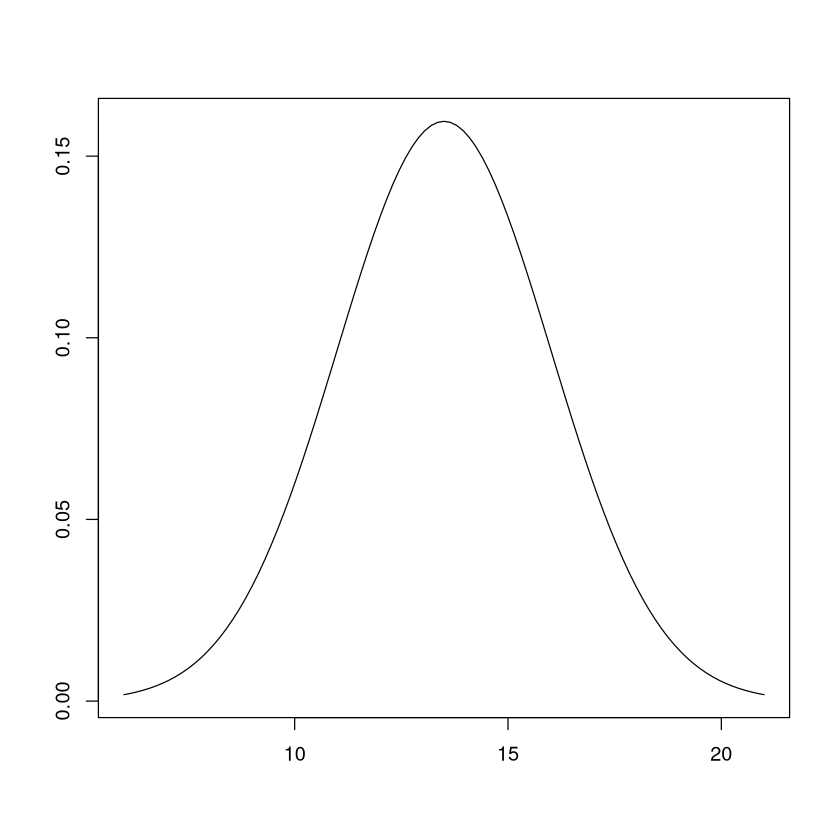

In [5]:
p.720 <- new.env()
p.720$mean <- 13.5
p.720$sd <- 2.5
p.720$limits <- 13.5 + c(-2.5*3,2.5*3)
curve(dnorm(x,p.720$mean,p.720$sd),xlim=p.720$limits, xlab="", ylab="")
rm(p.720)

---

## Problem 7-21
Determine the second quartile ($Q_2$), the third quartile ($Q_3$), and the 90th percentile ($P_{90}$) for the times that college students spend on the internet. Use the normal distribution given in [Problem 7-20](#Problem-7-20)

In [6]:
darea.xy <- function(mean, sd, step, q) {
    rmin = mean - sd*4
    rmax = mean + sd*4
    r = c(rmin, rmax)
    rInt = diff(r)
    coord.x = c(rmin, seq(rmin, q, step), q)
    coord.y = c(0, dnorm(seq(rmin, q, step), mean, sd), 0)
    return(list(coord.x, coord.y))
}

In [7]:
p721 <- new.env()
p721$mean <- 13.5
p721$sd <- 2.5
p721$step <- 0.01
p721$rmin <- p721$mean-p721$sd*4
p721$rmax <- p721$mean+p721$sd*4
p721$range <- c(p721$rmin, p721$rmax)
p721$rInt <- diff(p721$range)
p721$q <- c(.5, .75, .90)
p721$cov <- p721$rmin + p721$rInt*p721$q
p721$Q2 <- qnorm(p721$q[1], p721$mean, p721$sd)
p721$Q3 <- qnorm(p721$q[2], p721$mean, p721$sd)
p721$P90 <- qnorm(p721$q[3], p721$mean, p721$sd)
p721$Q2.coords <- darea.xy(p721$mean, p721$sd, p721$step, p721$Q2)
p721$Q3.coords <- darea.xy(p721$mean, p721$sd, p721$step, p721$Q3)
p721$P90.coords <- darea.xy(p721$mean, p721$sd, p721$step, p721$P90)

In [8]:
cat("Second Quartile: ", p721$Q2, "\n")
cat("Third Quartile: ", p721$Q3, "\n")
cat("90th Percentile: ", p721$P90, "\n")

Second Quartile:  13.5 
Third Quartile:  15.18622 
90th Percentile:  16.70388 


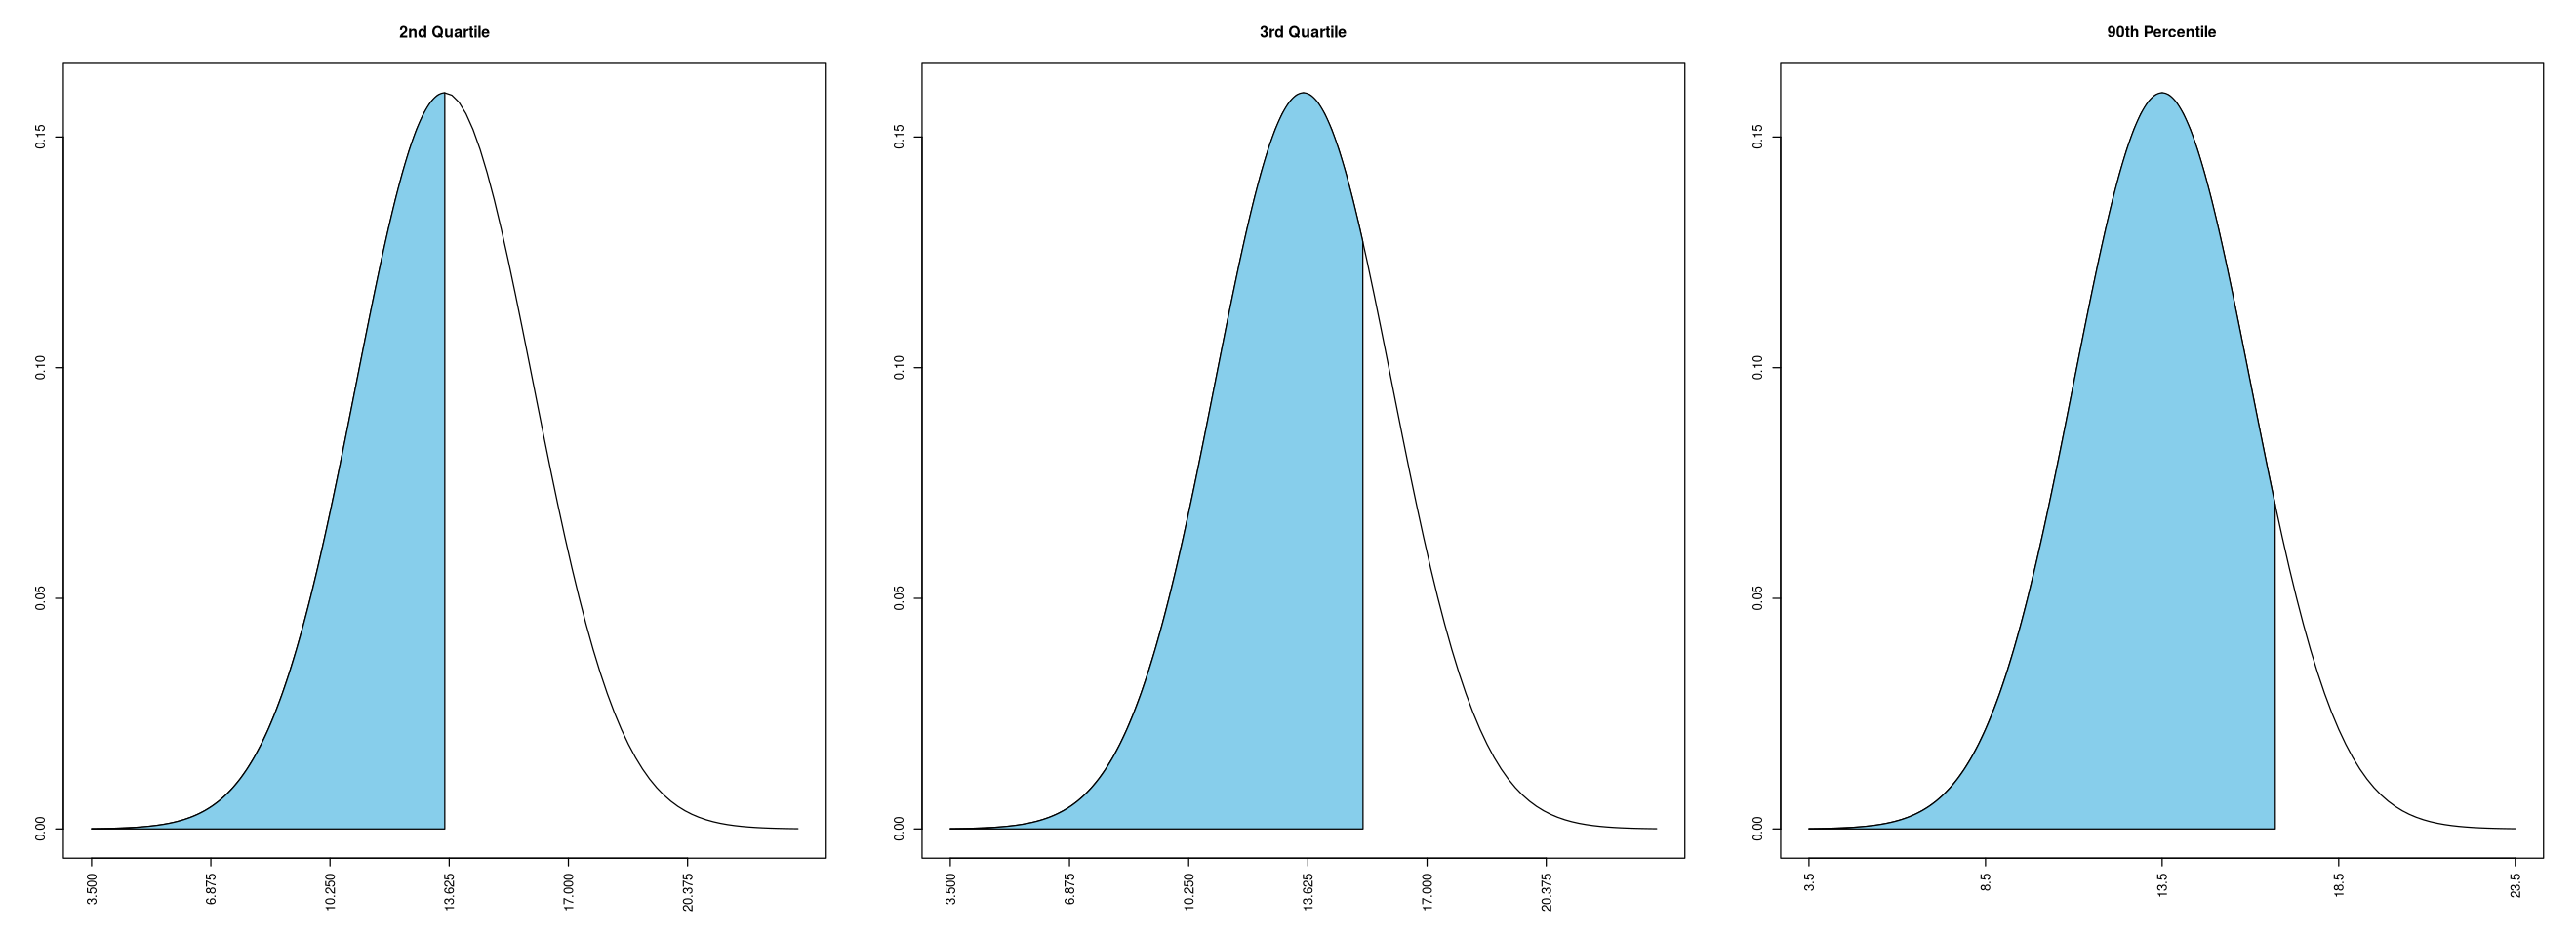

In [9]:
par(mfrow=c(1,3))
options(repr.plot.width=22, repr.plot.height=8)
curve(dnorm(x, p721$mean, p721$sd), xlim=p721$range, xlab="", ylab="", xaxt="n", main="2nd Quartile")
axis(1, at=seq(p721$rmin, p721$rmax, p721$mean/4), las=2)
polygon(p721$Q2.coords[[1]], p721$Q2.coords[[2]], col='skyblue')
curve(dnorm(x, p721$mean, p721$sd), xlim=p721$range, xlab="", ylab="", xaxt="n", main="3rd Quartile")
axis(1, at=seq(p721$rmin, p721$rmax, p721$mean/4), las=2)
polygon(p721$Q3.coords[[1]], p721$Q3.coords[[2]], col='skyblue')
curve(dnorm(x, p721$mean, p721$sd), xlim=p721$range, xlab="", ylab="", xaxt="n", main="90th Percentile")
axis(1, at=seq(p721$rmin, p721$rmax, p721$rInt/4), las=2)
polygon(p721$P90.coords[[1]], p721$P90.coords[[2]], col='skyblue')
options(repr.plot.width=7, repr.plot.height=7)

In [10]:
require(mosaic)

Loading required package: mosaic

Registered S3 method overwritten by 'mosaic':
  method                           from   
  fortify.SpatialPolygonsDataFrame ggplot2


The 'mosaic' package masks several functions from core packages in order to add 
additional features.  The original behavior of these functions should not be affected by this.


Attaching package: ‘mosaic’


The following objects are masked from ‘package:dplyr’:

    count, do, tally


The following object is masked from ‘package:Matrix’:

    mean


The following object is masked from ‘package:ggplot2’:

    stat


The following objects are masked from ‘package:stats’:

    binom.test, cor, cor.test, cov, fivenum, IQR, median, prop.test,
    quantile, sd, t.test, var


The following objects are masked from ‘package:base’:

    max, mean, min, prod, range, sample, sum







If X ~ N(13.5, 2.5), then 


	P(X <= 13.5) = P(Z <= 0) = 0.5

	P(X >  13.5) = P(Z >  0) = 0.5






[1] 0.5




If X ~ N(13.5, 2.5), then 


	P(X <= 15.19) = P(Z <= 0.6745) = 0.75

	P(X >  15.19) = P(Z >  0.6745) = 0.25






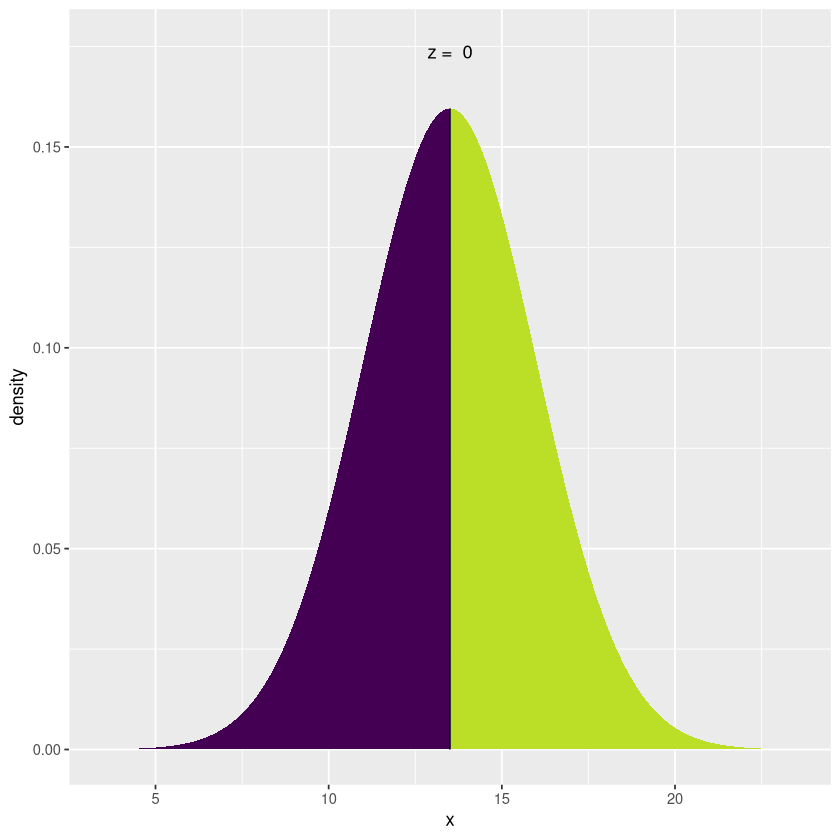

[1] 0.75




If X ~ N(13.5, 2.5), then 


	P(X <= 16.7) = P(Z <= 1.282) = 0.9

	P(X >  16.7) = P(Z >  1.282) = 0.1






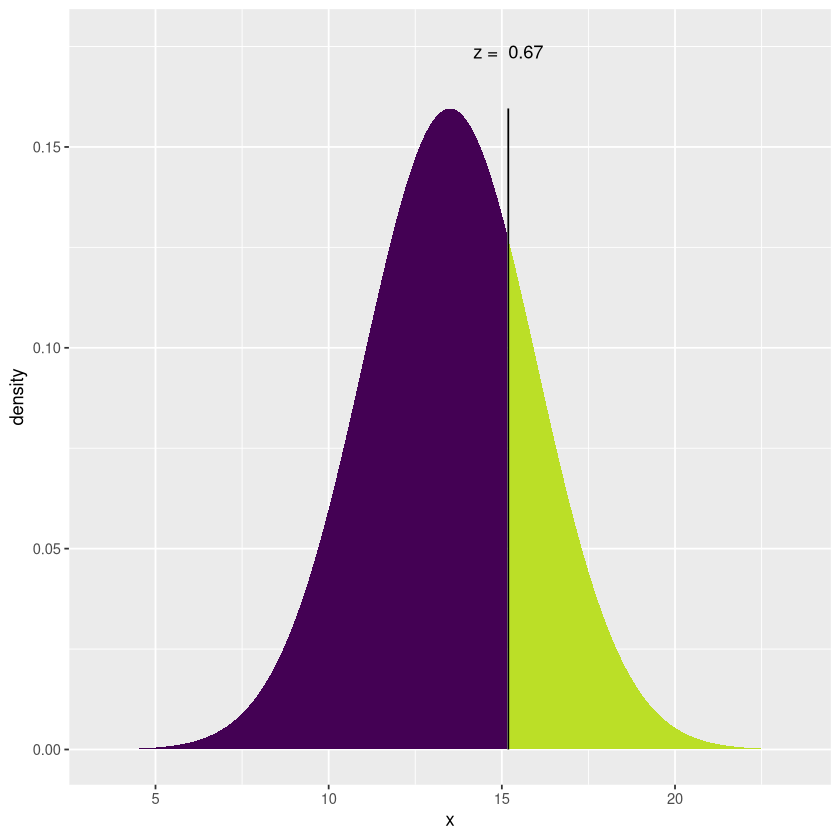

[1] 0.9

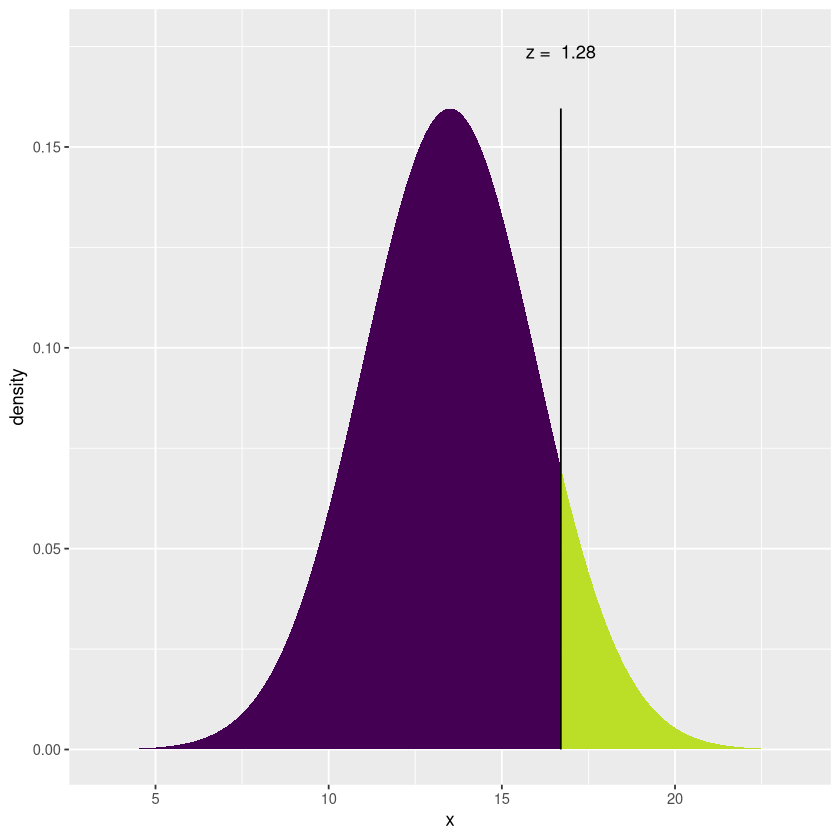

In [11]:
xpnorm(p721$Q2, p721$mean, p721$sd)
xpnorm(p721$Q3, p721$mean, p721$sd)
xpnorm(p721$P90, p721$mean, p721$sd)
rm(p721)

---